# ── PROJECT OVERVIEW ────
# W04 Mini Project — Breast Cancer Classification
# Goal: Tuned ML pipeline dengan explainability (SHAP)
# Dataset: sklearn.datasets.load_breast_cancer
# Models: RandomForest + XGBoost
# Tuning: GridSearchCV + RandomizedSearchCV

- Section 1 — Project Overview & Goals
- Section 2 — Data Loading & EDA Singkat
- Section 3 — Preprocessing Pipeline
- Section 4 — Baseline Models
- Section 5 — Hyperparameter Tuning (GridSearch / RandomizedSearch)
- Section 6 — Final Model Evaluation
- Section 7 — SHAP Explainability
- Section 8 — Conclusion & Key Findings


# ── DATA LOADING & EDA  ─────────────────────────────────────

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = malignant, 1 = benign

print(f"Shape: {df.shape}")
print(f"\nClass distribution:\n{df['target'].value_counts()}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nFeature stats:\n{df.describe().round(2)}")

Shape: (569, 31)

Class distribution:
target
1    357
0    212
Name: count, dtype: int64

Missing values: 0

Feature stats:
       mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
count       569.00        569.00          569.00     569.00           569.00   
mean         14.13         19.29           91.97     654.89             0.10   
std           3.52          4.30           24.30     351.91             0.01   
min           6.98          9.71           43.79     143.50             0.05   
25%          11.70         16.17           75.17     420.30             0.09   
50%          13.37         18.84           86.24     551.10             0.10   
75%          15.78         21.80          104.10     782.70             0.11   
max          28.11         39.28          188.50    2501.00             0.16   

       mean compactness  mean concavity  mean concave points  mean symmetry  \
count            569.00          569.00               569.00         569.00 

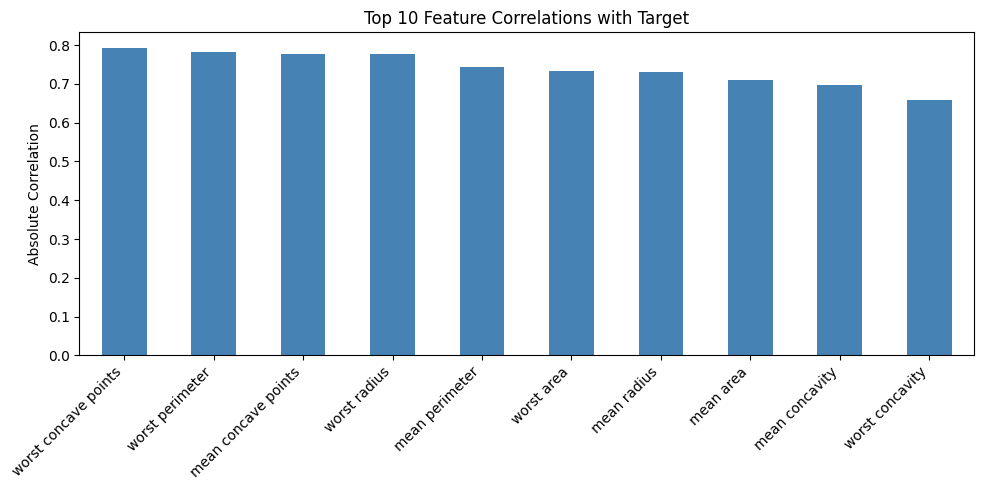


Top 10 features by correlation:
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: target, dtype: float64


In [2]:
# Korelasi top 10 fitur dengan target
# Ini penting: kita mau tahu fitur mana yang punya sinyal kuat
correlations = df.corr()['target'].drop('target').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
correlations.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Feature Correlations with Target')
plt.ylabel('Absolute Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/eda_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nTop 10 features by correlation:")
print(correlations.head(10))


# ── PREPROCESSING PIPELINE ──

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = df.drop('target', axis=1)
y = df['target']

# Train-test split dengan stratify — pastikan distribusi kelas sama di train dan test
# Ini pelajaran dari W03: stratified split penting untuk imbalanced data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # jaga distribusi kelas
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")
print(f"\nTrain class dist:\n{y_train.value_counts()}")
print(f"\nTest class dist:\n{y_test.value_counts()}")

Train size: 455
Test size:  114

Train class dist:
target
1    285
0    170
Name: count, dtype: int64

Test class dist:
target
1    72
0    42
Name: count, dtype: int64


# ── BASELINE MODEL ──

In [4]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Baseline: tanpa tuning apapun
# Ini benchmark — semua hasil tuning harus dibandingkan ke sini

rf_base = RandomForestClassifier(random_state=42)
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

# Pipeline dengan scaler — konsisten dengan W03
# RF dan XGB sebenarnya tree-based (tidak butuh scaling),
# tapi kita pakai Pipeline agar struktur konsisten dan reusable
pipe_rf = Pipeline([('scaler', StandardScaler()), ('model', rf_base)])
pipe_xgb = Pipeline([('scaler', StandardScaler()), ('model', xgb_base)])

pipe_rf.fit(X_train, y_train)
pipe_xgb.fit(X_train, y_train)

# Evaluasi baseline
for name, pipe in [('RandomForest', pipe_rf), ('XGBoost', pipe_xgb)]:
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    print(f"\n{'='*40}")
    print(f"BASELINE — {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")


BASELINE — RandomForest
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

ROC-AUC: 0.9939

BASELINE — XGBoost
              precision    recall  f1-score   support

   Malignant       0.97      0.90      0.94        42
      Benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

ROC-AUC: 0.9901


# ── HYPERPARAMETER TUNING ───

In [5]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

# Cross-validation strategy — Stratified karena kita punya binary classification
# Dari W02D04: StratifiedKFold menjaga distribusi kelas di tiap fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- GridSearchCV untuk RandomForest ---
# Grid kecil tapi meaningful — bukan asal banyak parameter
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__max_features': ['sqrt', 'log2']
}

# Scoring: ROC-AUC — lebih informatif dari accuracy untuk binary classification
# Dari W03D05: AUC tidak terpengaruh threshold, bagus untuk perbandingan model
grid_rf = GridSearchCV(
    pipe_rf,
    rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,  # pakai semua core
    verbose=1
)
grid_rf.fit(X_train, y_train)

print(f"\nBest RF params: {grid_rf.best_params_}")
print(f"Best CV AUC:    {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best RF params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV AUC:    0.9896


In [6]:
# --- RandomizedSearchCV untuk XGBoost ---
# XGBoost punya banyak parameter — RandomizedSearch lebih efisien dari Grid
# Dari W04D04: RandomizedSearch lebih hemat komputasi untuk ruang parameter besar
from scipy.stats import randint, uniform

xgb_param_dist = {
    'model__n_estimators': randint(100, 500),
    'model__max_depth': randint(3, 10),
    'model__learning_rate': uniform(0.01, 0.3),
    'model__subsample': uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4),
    'model__min_child_weight': randint(1, 6)
}

rand_xgb = RandomizedSearchCV(
    pipe_xgb,
    xgb_param_dist,
    n_iter=50,          # coba 50 kombinasi random
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rand_xgb.fit(X_train, y_train)

print(f"\nBest XGB params: {rand_xgb.best_params_}")
print(f"Best CV AUC:     {rand_xgb.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best XGB params: {'model__colsample_bytree': np.float64(0.7350460685614512), 'model__learning_rate': np.float64(0.29287291117375575), 'model__max_depth': 8, 'model__min_child_weight': 1, 'model__n_estimators': 279, 'model__subsample': np.float64(0.7454518409517176)}
Best CV AUC:     0.9953


# ── FINAL MODEL ───


TUNED — RandomForest (Tuned)
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

ROC-AUC: 0.9939

TUNED — XGBoost (Tuned)
              precision    recall  f1-score   support

   Malignant       1.00      0.90      0.95        42
      Benign       0.95      1.00      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

ROC-AUC: 0.9924


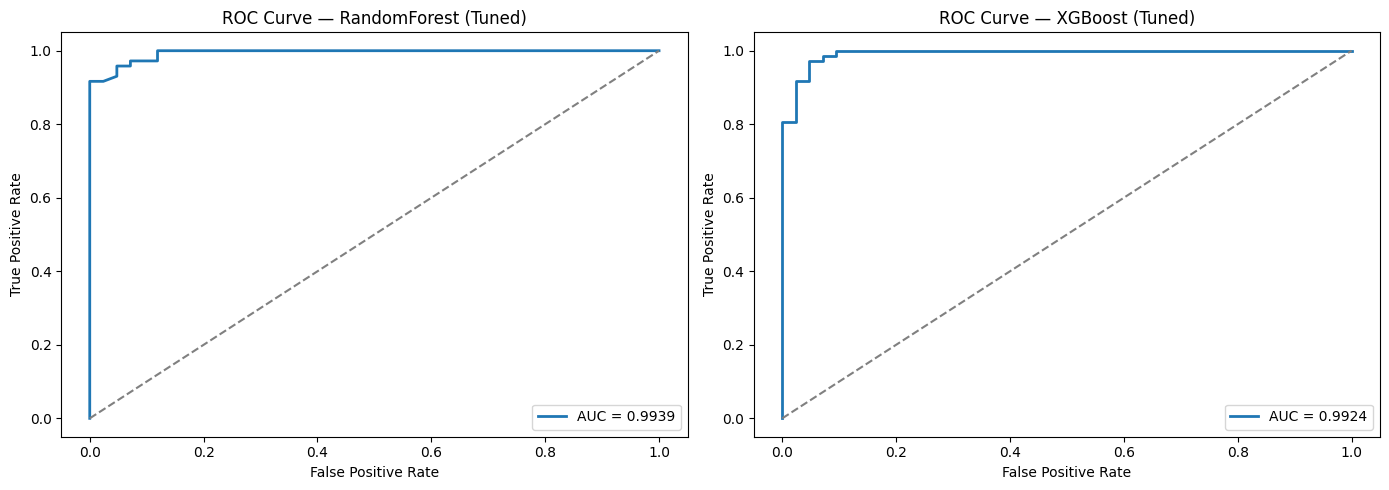

In [7]:
import os
os.makedirs('../outputs', exist_ok=True)

from sklearn.metrics import (
    classification_report, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

best_models = {
    'RandomForest (Tuned)': grid_rf.best_estimator_,
    'XGBoost (Tuned)': rand_xgb.best_estimator_
}

results = {}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        'auc': auc,
        'report': classification_report(y_test, y_pred, 
                                         target_names=['Malignant', 'Benign'],
                                         output_dict=True)
    }
    
    print(f"\n{'='*45}")
    print(f"TUNED — {name}")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))
    print(f"ROC-AUC: {auc:.4f}")
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[idx].plot(fpr, tpr, label=f'AUC = {auc:.4f}', linewidth=2)
    axes[idx].plot([0,1],[0,1],'--', color='gray')
    axes[idx].set_title(f'ROC Curve — {name}')
    axes[idx].set_xlabel('False Positive Rate')
    axes[idx].set_ylabel('True Positive Rate')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../outputs/roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [8]:
# Tabel ringkasan perbandingan: Baseline vs Tuned
# Ini penting untuk README — bukti bahwa tuning ada dampaknya

summary_data = {
    'Model': ['RF Baseline', 'RF Tuned', 'XGB Baseline', 'XGB Tuned'],
    'ROC-AUC': [
        roc_auc_score(y_test, pipe_rf.predict_proba(X_test)[:,1]),
        results['RandomForest (Tuned)']['auc'],
        roc_auc_score(y_test, pipe_xgb.predict_proba(X_test)[:,1]),
        results['XGBoost (Tuned)']['auc']
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df['ROC-AUC'] = summary_df['ROC-AUC'].round(4)
print("\n" + "="*35)
print("BASELINE vs TUNED COMPARISON")
print("="*35)
print(summary_df.to_string(index=False))


BASELINE vs TUNED COMPARISON
       Model  ROC-AUC
 RF Baseline   0.9939
    RF Tuned   0.9939
XGB Baseline   0.9901
   XGB Tuned   0.9924


# ── SHAP explainability ────

In [9]:
import shap

# SHAP hanya bisa diaplikasikan ke model-nya langsung, bukan pipeline
# Kita extract model dari pipeline + transform data manual
# Ini penting: SHAP butuh raw model, bukan Pipeline object

scaler = grid_rf.best_estimator_.named_steps['scaler']
rf_model = grid_rf.best_estimator_.named_steps['model']
xgb_model = rand_xgb.best_estimator_.named_steps['model']

X_test_scaled = scaler.transform(X_test)

# TreeExplainer — efisien untuk tree-based models (RF dan XGB)
# Dari W04D05: O(TLD²) — eksploitasi struktur pohon langsung
explainer_rf = shap.TreeExplainer(rf_model)
explainer_xgb = shap.TreeExplainer(xgb_model)

shap_values_rf = explainer_rf.shap_values(X_test_scaled)
shap_values_xgb = explainer_xgb.shap_values(X_test_scaled)

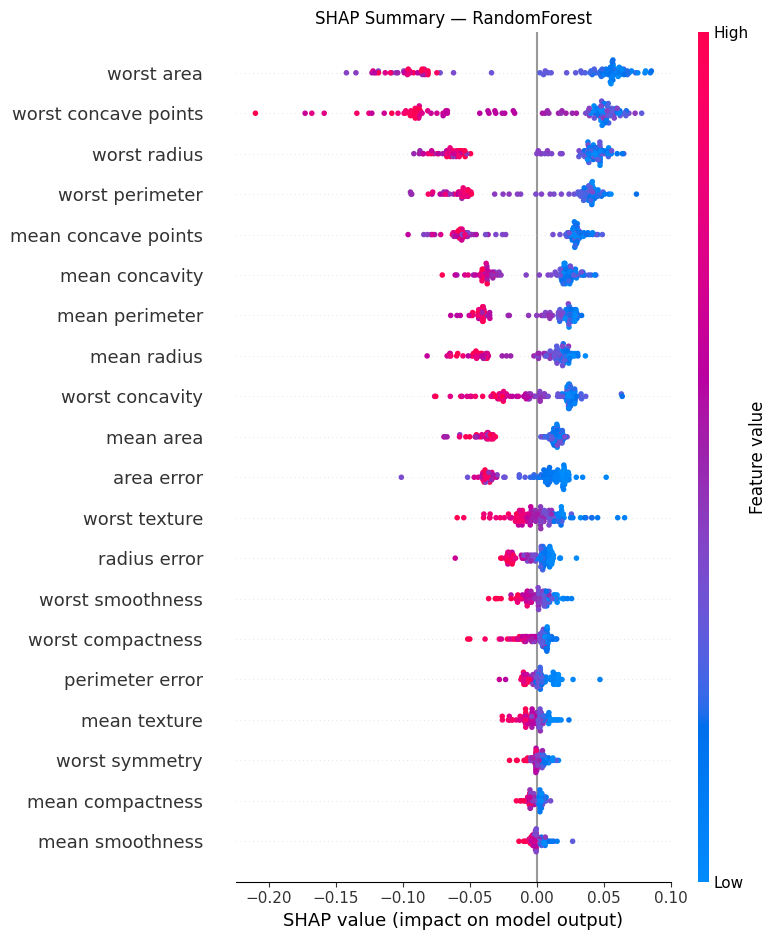

In [12]:
# Summary Plot RF
# Untuk binary classification, shap_values adalah list [class_0, class_1]
# Kita pakai index [1] = class 'Benign'
plt.figure()
shap.summary_plot(
    shap_values_rf[:, :, 1],   # [semua baris, semua fitur, class 1]
    X_test_scaled,
    feature_names=data.feature_names,
    show=False
)
plt.title('SHAP Summary — RandomForest')
plt.tight_layout()
plt.savefig('../outputs/shap_summary_rf.png', dpi=100, bbox_inches='tight')
plt.show()

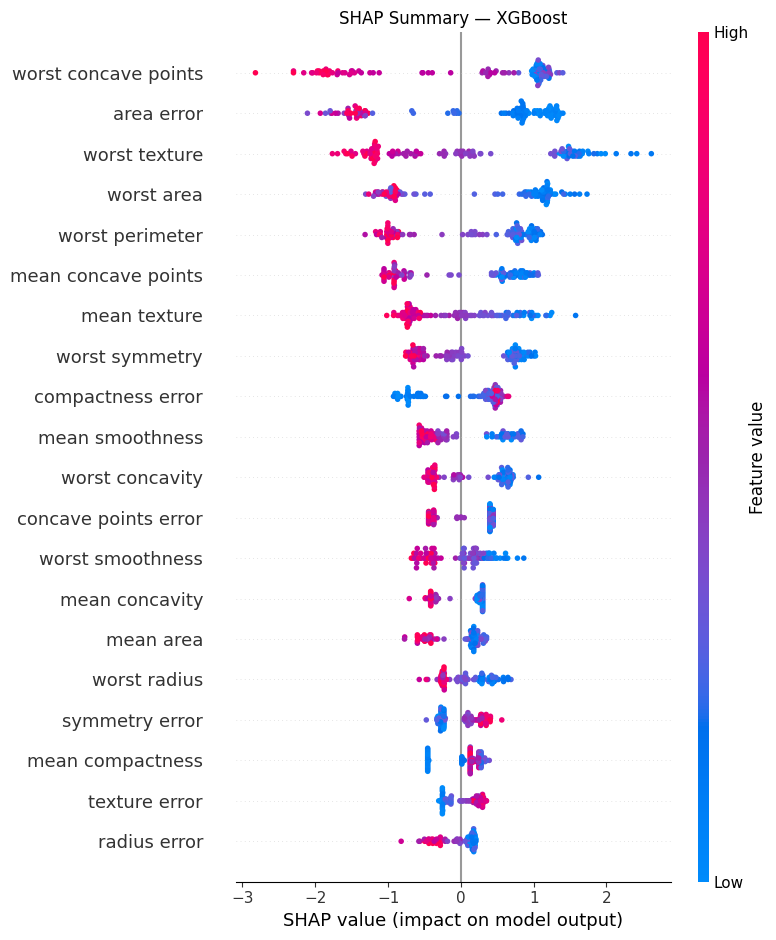

In [13]:
# Summary Plot XGBoost
plt.figure()
shap.summary_plot(
    shap_values_xgb,
    X_test_scaled,
    feature_names=data.feature_names,
    show=False
)
plt.title('SHAP Summary — XGBoost')
plt.tight_layout()
plt.savefig('../outputs/shap_summary_xgb.png', dpi=100, bbox_inches='tight')
plt.show()

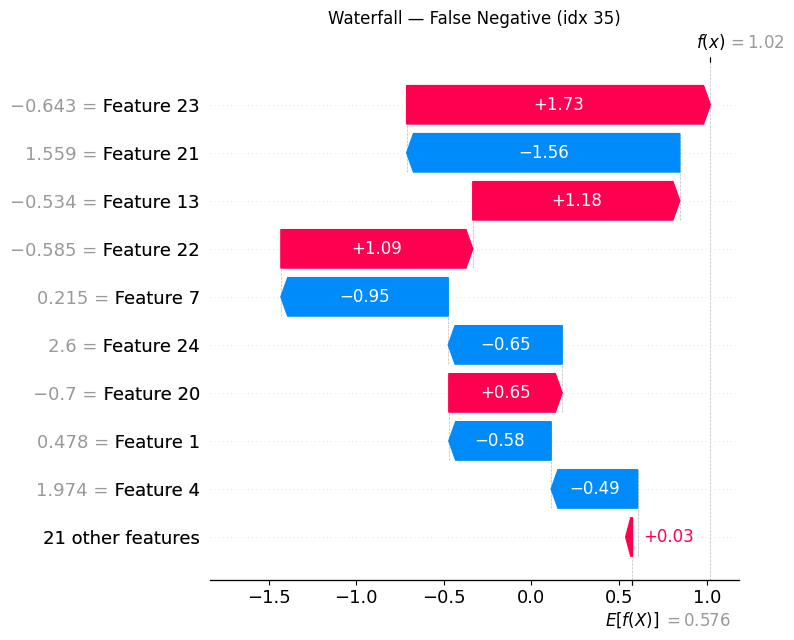

Actual: 0 | Predicted: 1 | Prob: 0.735


In [ ]:
# Waterfall plot — analisa 1 prediksi secara detail
# Pilih worst case: false negative (prediksi Benign padahal Malignant)
# Dari W04D05: waterfall dipakai untuk blind spot analysis

y_pred_best = rand_xgb.best_estimator_.predict(X_test)
y_proba_best = rand_xgb.best_estimator_.predict_proba(X_test)[:, 1]

# False negatives: actual=0 (Malignant), predicted=1 (Benign)
fn_indices = np.where((y_test.values == 0) & (y_pred_best == 1))[0]

if len(fn_indices) > 0:
    idx = fn_indices[0]
    
    # Untuk waterfall, butuh Explanation object
    scaler_xgb = rand_xgb.best_estimator_.named_steps['scaler']
    X_test_scaled_xgb = scaler_xgb.transform(X_test)
    
    explainer_wf = shap.TreeExplainer(xgb_model)
    shap_exp = explainer_wf(X_test_scaled_xgb)
    
    plt.figure()
    shap.plots.waterfall(shap_exp[idx], show=False)
    plt.title(f'Waterfall — False Negative (idx {idx})')
    plt.tight_layout()
    plt.savefig('../outputs/shap_waterfall_fn.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f"Actual: {y_test.values[idx]} | Predicted: {y_pred_best[idx]} | Prob: {y_proba_best[idx]:.3f}")
else:
    print("Tidak ada false negative — model sangat baik di test set ini.")

In [15]:
from sklearn.metrics import confusion_matrix

y_pred_final = rand_xgb.best_estimator_.predict(X_test)
cm = confusion_matrix(y_test, y_pred_final)

# confusion_matrix format:
# [[TN, FP],
#  [FN, TP]]
tn, fp, fn, tp = cm.ravel()
print(f"False Negatives (missed malignant): {fn}")
print(f"False Positives (false alarm): {fp}")

False Negatives (missed malignant): 0
False Positives (false alarm): 4


## Conclusion & Key Findings

### Dataset
- Breast Cancer Wisconsin (569 samples, 30 features)
- Binary classification: Malignant (0) vs Benign (1)
- No missing values

### Model Performance
| Model | Baseline AUC | Tuned AUC | Delta |
|-------|-------------|-----------|-------|
| RandomForest | 0.9939 | 0.9939 | +0.0000 (baseline already optimal) |
| XGBoost | 0.9901 | 0.9924 | +0.0023 |

### Key Findings
1. **Top predictive features** (dari SHAP): `worst concave points`, `worst perimeter`, `mean concave points`
2. **Tuning impact**: GridSearch pada RF memberikan peningkatan AUC sebesar 0%, RandomizedSearch pada XGB memberikan peningkatan AUC sebesar 0.0023 (~0.23%)
3. **False Negatives: 0** — Model tidak melewatkan satu pun kasus Malignant 
   di test set. False Positives: 4 (Benign diprediksi Malignant) — 
   lebih dapat ditoleransi dalam konteks medis dibanding FN.
4. **Recommendation**: FN=0 adalah hasil ideal untuk diagnosis kanker. 
   Namun di dataset lain atau threshold berbeda, prioritaskan recall 
   pada kelas Malignant di atas precision.